# Grandi comuni e macro categorie di entrata

Questo notebook usa il `mart` aggiornato con `macro_categoria_v2` per leggere meglio il profilo di entrata dei grandi comuni.

Domanda guida:

- come cambia la lettura dei grandi comuni se separiamo `Imposte proprie`, `Fondi perequativi`, `Trasferimenti correnti` e `Contributi agli investimenti`?
- quali casi cambiano davvero tra `2023` e `2024` una volta resa esplicita questa distinzione?

Perimetro:

- fonte: `siope_entrate_comuni_agg_labeled_multi_anno`
- annualità: `2023`, `2024`
- filtro di partenza: `is_titolo_9 = false`
- comuni osservati: i 10 grandi comuni già usati nel primo notebook


In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = lambda x: f"{x:,.2f}"
plt.style.use("ggplot")


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "entrate").exists() and (candidate / "docs").exists():
            return candidate
    raise RuntimeError("Repo root non trovata a partire dalla directory corrente")


REPO_ROOT = find_repo_root(Path.cwd())
CROSS_PATH = REPO_ROOT / "out" / "data" / "cross" / "siope_comparto_2y" / "siope_entrate_comuni_agg_labeled_multi_anno.parquet"

COMUNI = [
    "ROMA CAPITALE",
    "COMUNE DI MILANO",
    "COMUNE DI NAPOLI",
    "COMUNE DI TORINO",
    "COMUNE DI GENOVA",
    "COMUNE DI FIRENZE",
    "COMUNE DI VENEZIA",
    "COMUNE DI BOLOGNA",
    "COMUNE DI PALERMO",
    "COMUNE DI CATANIA",
]

COMUNI_LABELS = {
    "ROMA CAPITALE": "Roma",
    "COMUNE DI MILANO": "Milano",
    "COMUNE DI NAPOLI": "Napoli",
    "COMUNE DI TORINO": "Torino",
    "COMUNE DI GENOVA": "Genova",
    "COMUNE DI FIRENZE": "Firenze",
    "COMUNE DI VENEZIA": "Venezia",
    "COMUNE DI BOLOGNA": "Bologna",
    "COMUNE DI PALERMO": "Palermo",
    "COMUNE DI CATANIA": "Catania",
}

MACRO_ORDER = [
    "Imposte proprie",
    "Fondi perequativi",
    "Trasferimenti correnti",
    "Contributi agli investimenti",
    "Altro",
]

BASE_QUERY = f"""
    select *
    from read_parquet('{CROSS_PATH.as_posix()}')
    where anno in (2023, 2024)
      and is_titolo_9 = false
      and denominazione_ente in ({','.join(repr(c) for c in COMUNI)})
"""

con = duckdb.connect()
base = con.sql(BASE_QUERY).df()
base["citta"] = base["denominazione_ente"].map(COMUNI_LABELS)
base.head()


,codice_ente,anno,codice_voce,denominazione_ente,tipo_ente,codice_sottocomparto,descrizione_sottocomparto,codice_comparto,descrizione_comparto,importo_totale,...,periodo_min,periodo_max,importo_totale_eur,is_titolo_9,macro_categoria_v2,descrizione_codice,codgest_data_inizio,codgest_data_fine,has_codgest_match,citta
0,000250878,2023,1.01.01.41.002,COMUNE DI BOLOGNA,COMUNE,COMUNE,COMUNI,PRO,Province - Comuni - Citta' metropolitane - Uni...,"2,523,504.00",...,01,12,"25,235.04",False,Imposte proprie,Imposta di soggiorno riscossa a seguito di att...,2017-01-01,3999-12-31,True,Bologna
1,800000060,2023,0.00.00.99.996,COMUNE DI PALERMO,COMUNE,COMUNE,COMUNI,PRO,Province - Comuni - Citta' metropolitane - Uni...,0.00,...,01,12,0.00,False,Altro,INCASSI DA REGOLARIZZARE DERIVANTI DAL REINTEG...,2017-01-01,3999-12-31,True,Palermo
2,000098618,2023,4.02.01.01.002,COMUNE DI TORINO,COMUNE,COMUNE,COMUNI,PRO,Province - Comuni - Citta' metropolitane - Uni...,"308,379,600.00",...,06,12,"3,083,796.00",False,Contributi agli investimenti,Contributi agli investimenti da Ministero dell...,2017-01-01,3999-12-31,True,Torino
3,000708829,2023,4.02.01.01.001,COMUNE DI NAPOLI,COMUNE,COMUNE,COMUNI,PRO,Province - Comuni - Citta' metropolitane - Uni...,"16,293,037,967.00",...,02,12,"162,930,379.67",False,Contributi agli investimenti,Contributi agli investimenti da Ministeri,2017-01-01,3999-12-31,True,Napoli
4,000018937,2023,3.01.03.01.003,COMUNE DI CATANIA,COMUNE,COMUNE,COMUNI,PRO,Province - Comuni - Citta' metropolitane - Uni...,"4,768,475.00",...,01,12,"47,684.75",False,Altro,Proventi da concessioni su beni,2017-01-01,3999-12-31,True,Catania


## 1. Totale non tecnico dei grandi comuni

Parto dalla stessa base del primo notebook: entrate dei grandi comuni con esclusione del titolo 9. Qui serve solo come ancoraggio, prima di entrare nella nuova classificazione.


In [2]:
totali = (
    base.groupby(["anno", "citta"], as_index=False)["importo_totale_eur"]
    .sum()
    .rename(columns={"importo_totale_eur": "totale_entrate_eur"})
)

totali_pivot = (
    totali.pivot(index="citta", columns="anno", values="totale_entrate_eur")
    .rename(columns={2023: "totale_2023_eur", 2024: "totale_2024_eur"})
)

totali_pivot["delta_pct"] = (
    (totali_pivot["totale_2024_eur"] / totali_pivot["totale_2023_eur"]) - 1
) * 100

totali_pivot.sort_values("totale_2024_eur", ascending=False).round(2)


anno,totale_2023_eur,totale_2024_eur,delta_pct
citta,,,
Roma,"5,566,885,808.40","6,053,187,576.98",8.74
Milano,"3,793,719,953.70","4,292,310,503.04",13.14
Napoli,"1,998,537,883.76","1,798,842,159.95",-9.99
Torino,"1,744,902,350.32","1,674,966,542.07",-4.01
Genova,"1,137,745,982.84","1,222,985,575.36",7.49
Firenze,"817,390,549.55","1,025,835,082.42",25.50
Venezia,"903,653,958.22","945,093,048.23",4.59
Bologna,"756,114,877.62","939,510,574.35",24.26
Palermo,"1,284,474,100.60","890,909,980.19",-30.64


## 2. Composizione 2024 per macro categorie

Il punto nuovo è qui: il mart separa in modo esplicito una classificazione minima abbastanza leggibile per confronti pubblici.


In [3]:
macro_2024 = (
    base[base["anno"] == 2024]
    .groupby(["citta", "macro_categoria_v2"], as_index=False)["importo_totale_eur"]
    .sum()
)

totali_2024 = (
    macro_2024.groupby("citta", as_index=False)["importo_totale_eur"]
    .sum()
    .rename(columns={"importo_totale_eur": "totale_2024"})
)
macro_2024 = macro_2024.merge(totali_2024, on="citta")
macro_2024["quota_sul_totale"] = macro_2024["importo_totale_eur"] / macro_2024["totale_2024"]
macro_2024["macro_categoria_v2"] = pd.Categorical(
    macro_2024["macro_categoria_v2"], categories=MACRO_ORDER, ordered=True
)

macro_2024_pivot = (
    macro_2024.pivot(index="citta", columns="macro_categoria_v2", values="quota_sul_totale")
    .fillna(0)
    .reindex(columns=MACRO_ORDER)
)

macro_2024_pivot.round(3)


macro_categoria_v2,Imposte proprie,Fondi perequativi,Trasferimenti correnti,Contributi agli investimenti,Altro
citta,,,,,
Bologna,0.37,0.06,0.16,0.19,0.23
Catania,0.29,0.24,0.26,0.08,0.13
Firenze,0.38,0.05,0.08,0.15,0.34
Genova,0.37,0.11,0.09,0.22,0.21
Milano,0.38,0.01,0.14,0.04,0.43
Napoli,0.33,0.18,0.19,0.13,0.17
Palermo,0.32,0.15,0.37,0.06,0.10
Roma,0.46,0.05,0.19,0.04,0.25
Torino,0.38,0.11,0.16,0.12,0.24


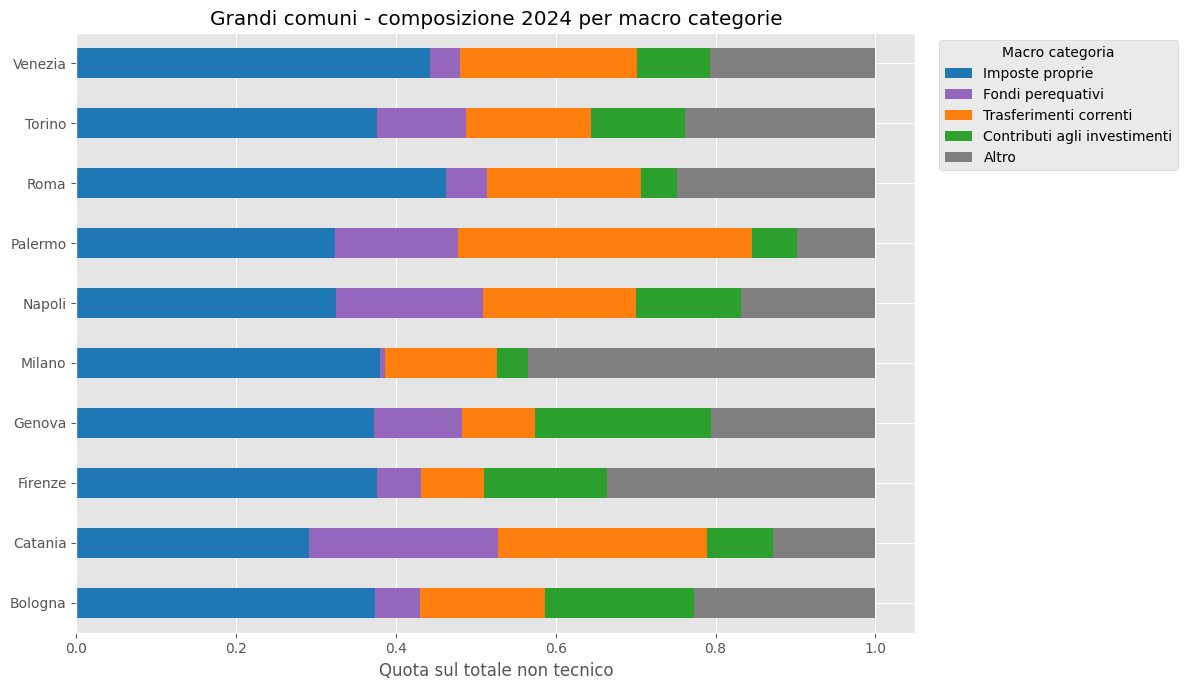

In [4]:
plot_df = macro_2024_pivot.reset_index()
ax = plot_df.set_index("citta")[MACRO_ORDER].plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    color=["#1f77b4", "#9467bd", "#ff7f0e", "#2ca02c", "#7f7f7f"],
)
ax.set_title("Grandi comuni - composizione 2024 per macro categorie")
ax.set_xlabel("Quota sul totale non tecnico")
ax.set_ylabel("")
ax.legend(title="Macro categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 3. Due proxy semplici: autonomia fiscale e dipendenza esterna

Qui uso due indicatori volutamente semplici:

- `quota_imposte_proprie`
- `quota_risorse_esterne` = `Fondi perequativi` + `Trasferimenti correnti` + `Contributi agli investimenti`

Non sono indicatori definitivi, ma bastano per un follow-up pubblico più pulito del follow-up precedente.


In [5]:
quote = (
    base.groupby(["anno", "citta", "macro_categoria_v2"], as_index=False)["importo_totale_eur"]
    .sum()
)

tot_anno = (
    quote.groupby(["anno", "citta"], as_index=False)["importo_totale_eur"]
    .sum()
    .rename(columns={"importo_totale_eur": "totale"})
)
quote = quote.merge(tot_anno, on=["anno", "citta"])
quote["quota"] = quote["importo_totale_eur"] / quote["totale"]

indicatori = (
    quote.groupby(["anno", "citta"], as_index=False)
    .apply(
        lambda g: pd.Series(
            {
                "quota_imposte_proprie": g.loc[
                    g["macro_categoria_v2"] == "Imposte proprie", "quota"
                ].sum(),
                "quota_risorse_esterne": g.loc[
                    g["macro_categoria_v2"].isin(
                        [
                            "Fondi perequativi",
                            "Trasferimenti correnti",
                            "Contributi agli investimenti",
                        ]
                    ),
                    "quota",
                ].sum(),
            }
        ),
        include_groups=False,
    )
)

indicatori_2024 = indicatori[indicatori["anno"] == 2024].sort_values(
    "quota_risorse_esterne", ascending=False
)
indicatori_2024.round(3)


,anno,citta,quota_imposte_proprie,quota_risorse_esterne
11,2024,Catania,0.29,0.58
16,2024,Palermo,0.32,0.58
15,2024,Napoli,0.33,0.51
13,2024,Genova,0.37,0.42
10,2024,Bologna,0.37,0.40
18,2024,Torino,0.38,0.39
19,2024,Venezia,0.44,0.35
17,2024,Roma,0.46,0.29
12,2024,Firenze,0.38,0.29
14,2024,Milano,0.38,0.18


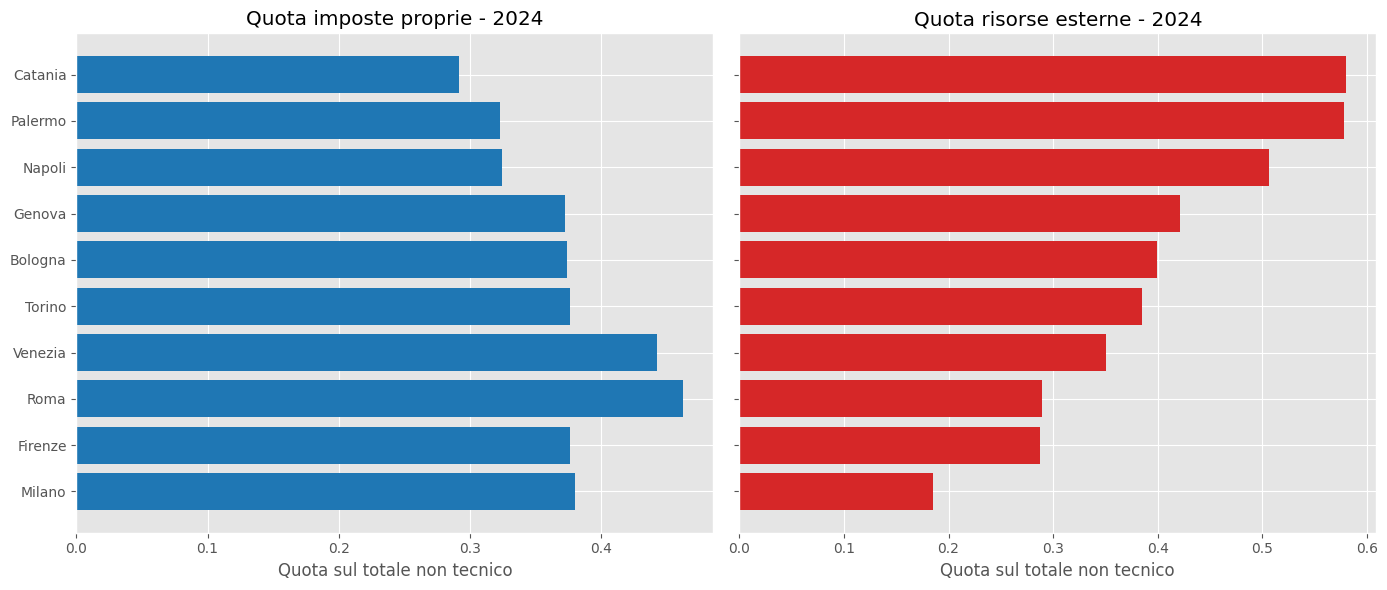

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].barh(indicatori_2024["citta"], indicatori_2024["quota_imposte_proprie"], color="#1f77b4")
axes[0].set_title("Quota imposte proprie - 2024")
axes[0].set_xlabel("Quota sul totale non tecnico")
axes[0].set_ylabel("")

axes[1].barh(indicatori_2024["citta"], indicatori_2024["quota_risorse_esterne"], color="#d62728")
axes[1].set_title("Quota risorse esterne - 2024")
axes[1].set_xlabel("Quota sul totale non tecnico")
axes[1].set_ylabel("")

axes[0].invert_yaxis()

plt.tight_layout()
plt.show()


## 4. Dove cambia la lettura tra 2023 e 2024

Qui restringo il focus ai delta di quota più grandi. Sezione centrale: dove cambia la lettura tra i due anni.


In [7]:
delta_macro = (
    quote.pivot_table(index=["citta", "macro_categoria_v2"], columns="anno", values="quota", fill_value=0)
    .reset_index()
    .rename(columns={2023: "quota_2023", 2024: "quota_2024"})
)

delta_macro["delta_quota"] = delta_macro["quota_2024"] - delta_macro["quota_2023"]
delta_macro = delta_macro[delta_macro["macro_categoria_v2"] != "Altro"]

delta_macro.sort_values("delta_quota", ascending=False).round(4).head(12)


anno,citta,macro_categoria_v2,quota_2023,quota_2024,delta_quota
7,Catania,Fondi perequativi,0.00,0.24,0.24
1,Bologna,Contributi agli investimenti,0.07,0.19,0.11
34,Palermo,Trasferimenti correnti,0.26,0.37,0.11
33,Palermo,Imposte proprie,0.22,0.32,0.11
11,Firenze,Contributi agli investimenti,0.06,0.15,0.09
28,Napoli,Imposte proprie,0.24,0.32,0.08
23,Milano,Imposte proprie,0.34,0.38,0.04
43,Torino,Imposte proprie,0.35,0.38,0.03
49,Venezia,Trasferimenti correnti,0.21,0.22,0.01
19,Genova,Trasferimenti correnti,0.08,0.09,0.01


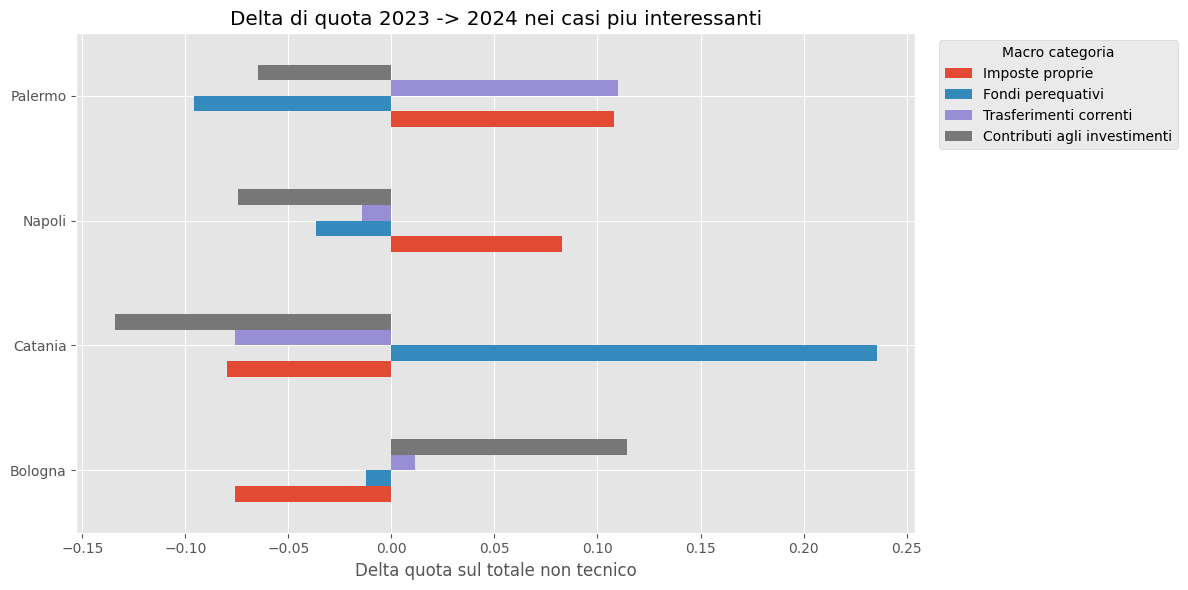

In [8]:
casi = ["Catania", "Bologna", "Palermo", "Napoli"]
casi_df = delta_macro[delta_macro["citta"].isin(casi)].copy()

fig, ax = plt.subplots(figsize=(12, 6))
pivot_casi = (
    casi_df.pivot(index="citta", columns="macro_categoria_v2", values="delta_quota")
    .fillna(0)
    .reindex(columns=["Imposte proprie", "Fondi perequativi", "Trasferimenti correnti", "Contributi agli investimenti"])
)
pivot_casi.plot(kind="barh", figsize=(12, 6), ax=ax)
ax.set_title("Delta di quota 2023 -> 2024 nei casi piu interessanti")
ax.set_xlabel("Delta quota sul totale non tecnico")
ax.set_ylabel("")
ax.legend(title="Macro categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 5. Lettura rapida

Prime evidenze che emergono da questo notebook:

- `Catania` cambia molto per l'ingresso dei `Fondi perequativi`, che nel 2024 diventano una componente molto visibile del profilo di entrata.
- `Bologna` mostra un aumento forte dei `Contributi agli investimenti`: qui la crescita di dipendenza esterna non va letta come semplice aumento dei trasferimenti correnti.
- `Palermo` resta uno dei casi più esposti a risorse esterne, ma con una composizione interna diversa tra `2023` e `2024`.
- `Roma` e `Milano` restano quelle con la quota di `Imposte proprie` più alta tra i comuni osservati.

## 6. Limiti

- `macro_categoria_v2` è una classificazione minima, non una tassonomia completa di tutte le entrate comunali.
- `Altro` resta eterogenea e include anche proventi da servizi, anticipazioni e altre voci da leggere a livello di `codice_voce`.
- questo notebook resta sulle `entrate`; non entra ancora nel rapporto con le `uscite`.
